# Выбор моделей для теста

Сранение цена/качество

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
df_costs = pd.read_excel('price_data/llm_prices.xlsx')
# df = df[df['КАТЕГОРИЯ'].str.lower().str.contains('общего назначения')]
df_costs['Цена вход'] = df_costs['ЦЕНА'].str.extract(r'Вход:\s*([\d.]+)').astype(float)
df_costs['Цена выход'] = df_costs['ЦЕНА'].str.extract(r'Выход:\s*([\d.]+)').astype(float)

# Вычисляем среднюю цену (примерно 1 токен вход = 1 токен выход)
df_costs['Средняя цена'] = (df_costs['Цена вход'] + df_costs['Цена выход']) / 2
df_costs.head()

,МОДЕЛЬ,ВЕНДОР,КАТЕГОРИЯ,ЦЕНА,Цена вход,Цена выход,Средняя цена
0,babbage-002\nopenai/babbage-002,OpenAI,Общего назначения,Вход: 43.20 ₽/М\nВыход: 43.20 ₽/М,43.2,43.2,43.2
1,davinci-002\nopenai/davinci-002,OpenAI,Общего назначения,Вход: 216 ₽/М\nВыход: 216 ₽/М,216.0,216.0,216.0
2,gpt-3.5-turbo\nopenai/gpt-3.5-turbo,OpenAI,Общего назначения,Вход: 54 ₽/М\nВыход: 162 ₽/М,54.0,162.0,108.0
3,gpt-3.5-turbo-16k\nopenai/gpt-3.5-turbo-16k,OpenAI,Общего назначения,Вход: 324 ₽/М\nВыход: 432 ₽/М,324.0,432.0,378.0
4,gpt-3.5-turbo-instruct\nopenai/gpt-3.5-turbo-i...,OpenAI,Общего назначения,Вход: 162 ₽/М\nВыход: 216 ₽/М,162.0,216.0,189.0


In [4]:
models = ['gpt-5.5\nopenai/gpt-5.5', 
        'gpt-5.1\nopenai/gpt-5.1', 
        'gpt-5.2\nopenai/gpt-5.2', 
        'gpt-4o\nopenai/gpt-4o', 
        'gpt-4o-mini\nopenai/gpt-4o-mini',

        'gemini-2.5-flash\ngoogle/gemini-2.5-flash',
        'gemini-2.5-flash-lite\ngoogle/gemini-2.5-flash-lite',
        'gemini-3.1-flash-lite\ngoogle/gemini-3.1-flash-lite',

        'qwen-2.5-72b-instruct\nqwen/qwen-2.5-72b-instruct',
        'qwen-2.5-7b-instruct\nqwen/qwen-2.5-7b-instruct',
        'qwen3-235b-a22b\nqwen/qwen3-235b-a22b',

        'deepseek-r1\ndeepseek/deepseek-r1',

        'claude-3-haiku\nanthropic/claude-3-haiku',
        'claude-haiku-4.5\nanthropic/claude-haiku-4.5',
        'claude-sonnet-4\nanthropic/claude-sonnet-4',
        ]


In [5]:
df_costs[df_costs['МОДЕЛЬ'].isin(models)].sort_values(by=['Цена вход', 'Цена выход'], ascending=False)

,МОДЕЛЬ,ВЕНДОР,КАТЕГОРИЯ,ЦЕНА,Цена вход,Цена выход,Средняя цена
43,gpt-5.5\nopenai/gpt-5.5,OpenAI,Общего назначения,Вход: 540 ₽/М\nВыход: 3240 ₽/М,540.00,3240.00,1890.00
80,claude-sonnet-4\nanthropic/claude-sonnet-4,Anthropic,Для кодирования,Вход: 324 ₽/М\nВыход: 1620 ₽/М,324.00,1620.00,972.00
10,gpt-4o\nopenai/gpt-4o,OpenAI,Общего назначения,Вход: 270 ₽/М\nВыход: 1080 ₽/М,270.00,1080.00,675.00
31,gpt-5.2\nopenai/gpt-5.2,OpenAI,Общего назначения,Вход: 189 ₽/М\nВыход: 1512 ₽/М,189.00,1512.00,850.50
25,gpt-5.1\nopenai/gpt-5.1,OpenAI,Общего назначения,Вход: 135 ₽/М\nВыход: 1080 ₽/М,135.00,1080.00,607.50
71,claude-haiku-4.5\nanthropic/claude-haiku-4.5,Anthropic,Общего назначения,Вход: 108 ₽/М\nВыход: 540 ₽/М,108.00,540.00,324.00
147,deepseek-r1\ndeepseek/deepseek-r1,DeepSeek,Общего назначения\nОпенсорсные,Вход: 75.60 ₽/М\nВыход: 270 ₽/М,75.60,270.00,172.80
206,qwen3-235b-a22b\nqwen/qwen3-235b-a22b,Qwen,Общего назначения\nОпенсорсные,Вход: 49.14 ₽/М\nВыход: 196.56 ₽/М,49.14,196.56,122.85
200,qwen-2.5-72b-instruct\nqwen/qwen-2.5-72b-instruct,Qwen,Общего назначения\nОпенсорсные,Вход: 38.88 ₽/М\nВыход: 43.20 ₽/М,38.88,43.20,41.04
83,gemini-2.5-flash\ngoogle/gemini-2.5-flash,Google,Общего назначения,Вход: 32.40 ₽/М\nВыход: 270 ₽/М,32.40,270.00,151.20


| Модель               | Роль в эксперименте                                  |
| -------------------- | ---------------------------------------------------- |
| **GPT-4o-mini**      | Бюджетная модель — минимальная стоимость             |
| **Gemini 2.5 Flash** | Оптимальный баланс качества и цены                   |
| **Claude Haiku 4.5** | Более качественная модель среднего ценового сегмента |


In [6]:

choose_models  = [
    'gpt-4o-mini\nopenai/gpt-4o-mini',
    'gemini-2.5-flash\ngoogle/gemini-2.5-flash',
    'claude-haiku-4.5\nanthropic/claude-haiku-4.5',
]
df_costs[df_costs['МОДЕЛЬ'].isin(choose_models)].sort_values(by=['Цена вход', 'Цена выход'], ascending=False)

,МОДЕЛЬ,ВЕНДОР,КАТЕГОРИЯ,ЦЕНА,Цена вход,Цена выход,Средняя цена
71,claude-haiku-4.5\nanthropic/claude-haiku-4.5,Anthropic,Общего назначения,Вход: 108 ₽/М\nВыход: 540 ₽/М,108.0,540.0,324.0
83,gemini-2.5-flash\ngoogle/gemini-2.5-flash,Google,Общего назначения,Вход: 32.40 ₽/М\nВыход: 270 ₽/М,32.4,270.0,151.2
11,gpt-4o-mini\nopenai/gpt-4o-mini,OpenAI,Общего назначения,Вход: 16.20 ₽/М\nВыход: 64.80 ₽/М,16.2,64.8,40.5


# Сравнение по цене и скорости

Сколько суммарно тратим за весь воркфлоу 

In [7]:
llm_models = [
    'openai/gpt-4o-mini',
    'google/gemini-2.5-flash',
    'anthropic/claude-haiku-4.5',
]

 # atomizer

In [8]:
llm_logs = pd.read_csv('price_data/llm-logs_2026-05-28_2026-06-28.csv')
llm_logs = llm_logs[llm_logs['success']]
llm_logs.head()

,event_time,api_key_name,model,success,status,duration_ms,input_tokens,output_tokens,cache_read_tokens,cache_creation_tokens,reasoning_tokens,total_tokens,amount_rub
1,2026-06-27T23:58:22.647112+00:00,Test API key,openai/gpt-5.1,True,success,8684,2781,1024,2048,0,0,3805,1.0271
2,2026-06-27T23:58:12.036117+00:00,Test API key,openai/gpt-5.1,True,success,9560,2813,974,2048,0,0,3787,0.9857
3,2026-06-27T23:57:59.149577+00:00,Test API key,openai/gpt-5.1,True,success,12574,2874,1436,2048,0,0,4310,1.4084
6,2026-06-27T23:57:42.476642+00:00,Test API key,openai/gpt-5.1,True,success,12743,3214,1423,2048,0,0,4637,1.4349
7,2026-06-27T23:57:27.391523+00:00,Test API key,openai/gpt-5.1,True,success,14570,3139,1508,0,0,0,4647,1.7103


In [9]:
# среднее кол-во токенов которые потребляем на этапе атомайзера
atomizer_test = llm_logs[llm_logs['model'].isin(llm_models)]
atomizer_test['input_tokens'].mean(), atomizer_test['output_tokens'].mean()

(np.float64(4289.594947025264), np.float64(1237.4458027709861))

In [10]:
atomizer_test.groupby('model').agg({'duration_ms': 'mean', 'amount_rub': 'mean'})

,duration_ms,amount_rub
model,,
anthropic/claude-haiku-4.5,6892.130000,1.139859
google/gemini-2.5-flash,6623.702500,0.411176
openai/gpt-4o-mini,10268.770492,0.084413


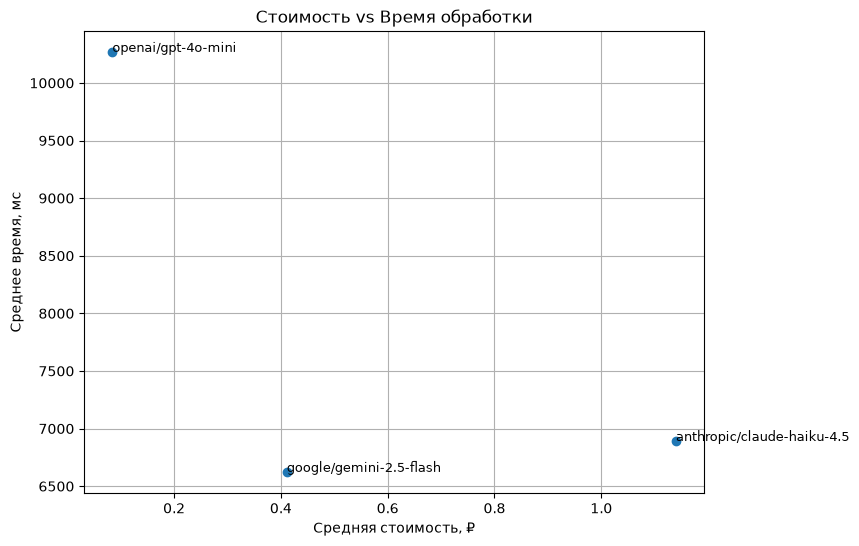

In [11]:
df_plot = (
    atomizer_test
    .groupby('model')[['duration_ms', 'amount_rub']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(8,6))

plt.scatter(df_plot['amount_rub'], df_plot['duration_ms'])

for _, row in df_plot.iterrows():
    plt.text(row['amount_rub'],
             row['duration_ms'],
             row['model'],
             fontsize=9)

plt.xlabel('Средняя стоимость, ₽')
plt.ylabel('Среднее время, мс')
plt.title('Стоимость vs Время обработки')
plt.grid(True)
plt.show()

In [12]:
#в среднем на этапе атомайзера тратится для модели gemini-2.5-flash 
atomizer_test[atomizer_test['model'] == 'google/gemini-2.5-flash']['amount_rub'].mean(),atomizer_test[atomizer_test['model'] == 'google/gemini-2.5-flash']['input_tokens'].mean(),atomizer_test[atomizer_test['model'] == 'google/gemini-2.5-flash']['output_tokens'].mean(),

(np.float64(0.41117625), np.float64(1321.675), np.float64(1668.845))

In [ ]:
# Если нужно посмотреть общие траты вообще на всё (включая gpt-5.1 для генерации)
llm_logs.groupby('model')['amount_rub'].mean().reset_index().sort_values(by='amount_rub', ascending=False)


,model,amount_rub
6,openai/gpt-5.5,2.952437
5,openai/gpt-5.2,2.047031
4,openai/gpt-5.1,1.275562
0,anthropic/claude-haiku-4.5,1.139859
9,qwen/qwen3-235b-a22b,1.118777
2,openai/gpt-4o,0.633303
1,google/gemini-2.5-flash,0.411176
8,qwen/qwen-2.5-72b-instruct,0.251543
3,openai/gpt-4o-mini,0.084413
7,openai/text-embedding-3-small,0.000200


In [21]:
# Если нужно посмотреть общие траты вообще на всё (включая gpt-5.1 для генерации)
llm_logs[llm_logs['model'].isin(llm_models)].groupby('model')['amount_rub'].mean().reset_index().sort_values(by='amount_rub', ascending=False)


,model,amount_rub
0,anthropic/claude-haiku-4.5,1.139859
1,google/gemini-2.5-flash,0.411176
2,openai/gpt-4o-mini,0.084413


In [23]:
# Если нужно посмотреть общие траты вообще на всё (включая gpt-5.1 для генерации)
llm_logs.groupby('model')['amount_rub'].sum().reset_index().sort_values(by='amount_rub', ascending=False)



,model,amount_rub
6,openai/gpt-5.5,1535.2670
5,openai/gpt-5.2,468.7702
0,anthropic/claude-haiku-4.5,455.9437
4,openai/gpt-5.1,225.7745
2,openai/gpt-4o,168.4585
1,google/gemini-2.5-flash,164.4705
9,qwen/qwen3-235b-a22b,83.9083
3,openai/gpt-4o-mini,36.0443
8,qwen/qwen-2.5-72b-instruct,5.2824
7,openai/text-embedding-3-small,0.0004


In [22]:
# Если нужно посмотреть общие траты вообще на всё (включая gpt-5.1 для генерации)
llm_logs[llm_logs['model'].isin(llm_models)].groupby('model')['amount_rub'].sum().reset_index().sort_values(by='amount_rub', ascending=False)


,model,amount_rub
0,anthropic/claude-haiku-4.5,455.9437
1,google/gemini-2.5-flash,164.4705
2,openai/gpt-4o-mini,36.0443


In [15]:
# Вытаскиваем чистое название модели
df_costs['clean_model_name'] = df_costs['МОДЕЛЬ'].apply(
    lambda x: x.split('\n')[-1] if '\n' in x else x
)

# Оставляем в логах только те модели, которые относятся к оценке Атомайзера
atomizer_models = [
    'openai/gpt-4o-mini',
    'google/gemini-2.5-flash',
    'anthropic/claude-haiku-4.5'
]
atomizer_logs = llm_logs[llm_logs['model'].isin(atomizer_models)].copy()

# Подтягиваем цены к логам
merged_logs = atomizer_logs.merge(
    df_costs[['clean_model_name', 'Цена вход', 'Цена выход']],
    left_on='model',
    right_on='clean_model_name',
    how='inner' # inner отсечет всё, чего нет в прайс-листе
)

# Рассчитываем стоимость для каждого лога
# Формула: (кол-во токенов / 1 000 000) * цена за миллион
merged_logs['calculated_cost'] = (
    (merged_logs['input_tokens'] / 1_000_000) * merged_logs['Цена вход'] +
    (merged_logs['output_tokens'] / 1_000_000) * merged_logs['Цена выход']
)

# Агрегируем итоговую статистику по моделям
final_costs = merged_logs.groupby('model').agg(
    total_calls=('model', 'count'),
    total_input_tokens=('input_tokens', 'sum'),
    total_output_tokens=('output_tokens', 'sum'),
    total_cost_rub=('calculated_cost', 'sum')
).reset_index()

print("\n--- Траты по тарифам из df_costs (только тестовые модели) ---")
display(final_costs)

# Общая сумма потраченная на тест Атомайзера
total_atomizer_money = final_costs['total_cost_rub'].sum()
print(f"\nИтого на прогон Атомайзера потрачено: {total_atomizer_money:.2f} ₽")


--- Траты по тарифам из df_costs (только тестовые модели) ---


,model,total_calls,total_input_tokens,total_output_tokens,total_cost_rub
0,anthropic/claude-haiku-4.5,400,2685676,476073,547.132428
1,google/gemini-2.5-flash,400,528670,667538,197.364168
2,openai/gpt-4o-mini,427,2048987,374735,57.476417



Итого на прогон Атомайзера потрачено: 801.97 ₽
